In [1]:

import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib
from retrieval_base.retrieval import Retrieval
import retrieval_base.auxiliary_functions as af
from retrieval_base.config import Config


path = af.get_path(return_pathlib=True)
path_figures = pathlib.Path('/home/dario/phd/twa2x_paper/figures')

config_file = 'config_jwst.txt'
w_set='NIRSpec'


def load_data(target, run):
    cwd = os.getcwd()
    if target not in cwd:
        os.chdir(f'{path}/{target}')
        print(f'Changed directory to {target}')

    conf = Config(path=path, target=target, run=run)(config_file)        
        
    m_spec = af.pickle_load(f'{conf.prefix}data/bestfit_m_spec_NIRSpec.pkl')
    m_spec.flux = m_spec.flux.squeeze()
    d_spec = af.pickle_load(f'{conf.prefix}data/d_spec_NIRSpec.pkl')
    
    Cov = af.pickle_load(f'{conf.prefix}data/bestfit_Cov_NIRSpec.pkl')
    LogLike = af.pickle_load(f'{conf.prefix}data/bestfit_LogLike_NIRSpec.pkl')
    err = np.nan * np.ones_like(d_spec.flux)
    
    for i in range(d_spec.n_orders):
        for j in range(d_spec.n_dets):
            # mask_i = d_spec.mask_isfinite[i,]
            mask_ij = d_spec.mask_isfinite[i,j]

            if Cov is not None:
                err_ij = Cov[i,j].get_err(mask=mask_ij)
            else:
                err_ij = d_spec.err[i,j]
                    
            beta_ij = LogLike.beta[i,j]
            err_ij *= beta_ij # optimal uncertainty scaling
            err[i,j,:] = err_ij
        
    flux_factor = conf.config_data['NIRSpec'].get('flux_unit_factor', 1.0)
    
    d_spec.err = err
    d_spec.squeeze()
    m_spec.flux.squeeze()

    m_spec.flux /= flux_factor
    d_spec.flux /= flux_factor
    d_spec.err /= flux_factor
    return d_spec, m_spec

In [5]:
runs = dict(TWA28='no_psf_corr_lbl10_G2G3_newGP_0',
            TWA27A='no_psf_corr_lbl10_G2G3_newGP_0',
            )

d_specs, m_specs = {}, {}
for target in runs.keys():
    
    try:
        d_specs[target], m_specs[target] = load_data(target, runs[target])
    except Exception as e:
        print(f'Error loading data for {target}: {e}')
        continue
    
runs = {k:v for k,v in runs.items() if k in d_specs.keys()}

Changed directory to TWA28
Changed directory to TWA27A


In [6]:
def fig_ax():
    fig, ax = plt.subplots(2,1, figsize=(14,5), sharex=True, gridspec_kw={'height_ratios':[3,1]},
                           tight_layout=True)
    return fig, ax

def plot_chunk(d_spec, m_spec, ax=None, idx=0, relative_residuals=False, colors=None, offset=0.0, ls='-', lw=1.4, new_fig=False,
               color_residuals=None, ylim_p=None):
    
    new_ax = (ax is None)
    if new_ax:
        fig, ax = plt.subplots(2,1, figsize=(10,5), sharex=True)
    else:
        assert len(ax) == 2, f'ax must be a list of 2 elements, not {len(ax)}'
        
    wave = d_spec.wave[idx]
    flux = d_spec.flux[idx] + offset
    err = d_spec.err[idx]
    nans = np.isnan(flux)
    m_flux = m_spec.flux[idx] + offset
    m_flux_nans = np.where(~nans, np.nan, m_flux)
    
    ax[0].plot(wave, flux, color=colors['data'], lw=lw, alpha=0.8, ls=ls)
    ax[0].plot(wave, flux, color=colors['data'], ls='none', marker='o', ms=2, alpha=0.8)
    ax[0].fill_between(wave, flux - err, flux + err, color=colors['data'], alpha=0.2, lw=0.0)
    ax[0].plot(wave, m_flux, color=colors['model'], lw=lw, alpha=0.8, ls=ls, label=target)
    # ax[0].plot(wave, m_flux_nans, color='red', lw=lw, alpha=0.8, ls=ls)
    
    res = flux - m_flux
    if relative_residuals:
        res_norm = res / flux
        err_norm = err / flux
        
    MAD = np.nanmedian(np.abs(res_norm))
    
    color_residuals = colors['model'] if color_residuals is None else color_residuals
    ax[1].plot(wave, res_norm, color=color_residuals, lw=lw, alpha=0.4)
    ax[1].scatter(wave, res_norm, color=color_residuals, s=6, alpha=0.8)
    ax[1].fill_between(wave, -err_norm, err_norm, color=colors['model'], alpha=0.3, lw=0.0)
    ax[1].axhline(0.0,color=colors['data'], lw=0.7)
    # if new_ax:
    
    ax[1].set_xlabel('Wavelength / nm')
    ax[0].set_ylabel('Flux / erg/s/cm2/nm') 
    if ylim_p is not None:
        p = np.nanpercentile(flux, ylim_p)
        ax[0].set_ylim(p[0], p[1])
    
    res_label = r'$\Delta F / F$' if relative_residuals else r'$\Delta F / erg/s/cm^2/nm$'
    ax[1].set_ylabel(res_label)
    
    if new_fig:
        
    
        ylim = - MAD*6.0, MAD*6.0
        ax[1].set_ylim(ylim)
        ax[1].text(0.02, 0.95, f'MAD = {MAD*100.0:.1f} %', transform=ax[1].transAxes,
                ha='left', va='top', fontsize=12)
        xlim = np.nanmin(wave[~nans])-2.0, np.nanmax(wave[~nans])+2.0
        ax[0].set_xlim(xlim)
        ax[1].set_xlim(xlim)
    
    # ax[1].axhline(0.0,color=colors['model'], lw=0.7)
        # ax.set_title(f'Chunk {idx}')
        # plt.show()
    return ax, wave, flux, err

colors = dict(TWA28={'data':'k', 'model':'orange'},
              TWA27A={'data':'k', 'model':'green'})

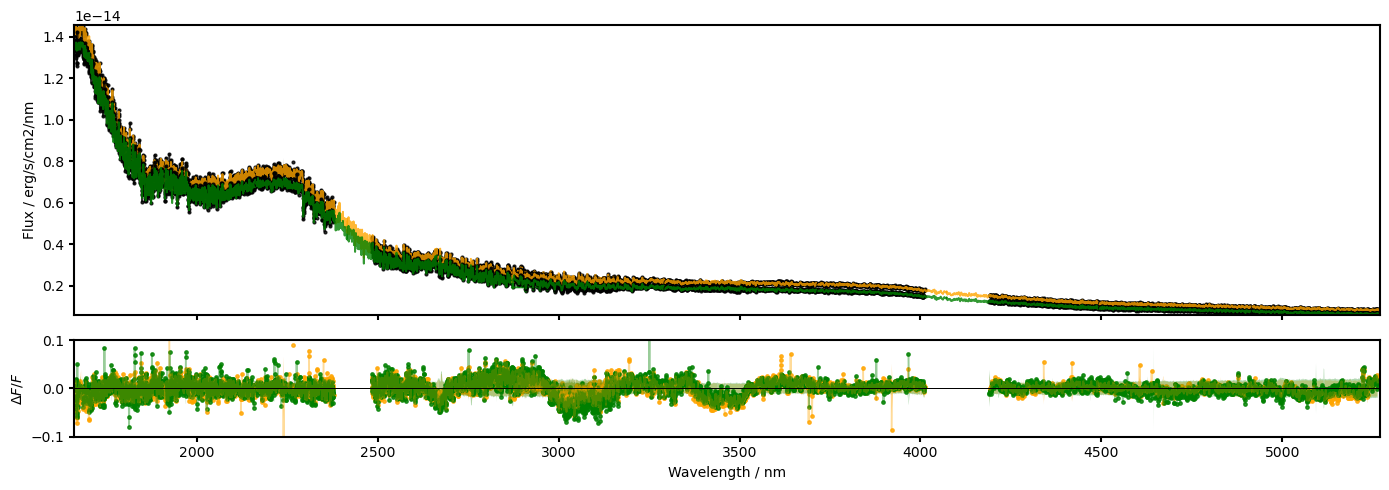

In [7]:
def plot_idx(idx, fig=None, ax=None, ylim_p=None, ylim=None, targets=None):  
    new_fig = False
    if fig is None or ax is None:
        fig, ax = fig_ax()
        new_fig = True
        ax[0].set_ylim(ylim[0], ylim[1])
        
    if targets is None:
        targets = runs.keys()
    for target in targets:
        d_spec, m_spec = d_specs[target], m_specs[target]
    # assert len(ax) == 2, f'ax must be a list of 2 elements, not {len(ax)}'
        _, wave, flux, err = plot_chunk(d_spec, m_spec, ax=ax, relative_residuals=True, 
                                        idx=idx,
                                        colors=colors[target],
                                        new_fig=new_fig,
                                        color_residuals=colors[target]['model'],
                                        ylim_p=ylim_p)
        
    return wave, flux, err
         
fig, ax = fig_ax()
xlim = np.nanmin(d_specs['TWA28'].wave), np.nanmax(d_specs['TWA28'].wave)
ymin = np.nanmin([d_specs[t].flux for t in runs.keys()])
ymax = np.nanmax([d_specs[t].flux for t in runs.keys()])
ax[0].set_xlim(xlim)
ax[0].set_ylim(ymin, ymax)
ax[1].set_xlim(xlim)
ax[1].set_ylim(-0.1, 0.1)
for idx in range(d_specs['TWA28'].flux.shape[0]):
    plot_idx(idx, fig=fig, ax=ax)

In [8]:
d_specs['TWA28'].flux.shape

(12, 636)

In [9]:
np.min(np.array([np.nanmin(d_specs[t].flux, axis=(1)) for t in runs.keys()]),axis=0)

array([5.991470e-15, 5.542272e-15, 4.601191e-15, 2.572120e-15,
       1.745911e-15, 1.655395e-15, 1.710653e-15, 1.677174e-15,
       1.430223e-15, 8.820210e-16, 6.739714e-16, 5.897734e-16])

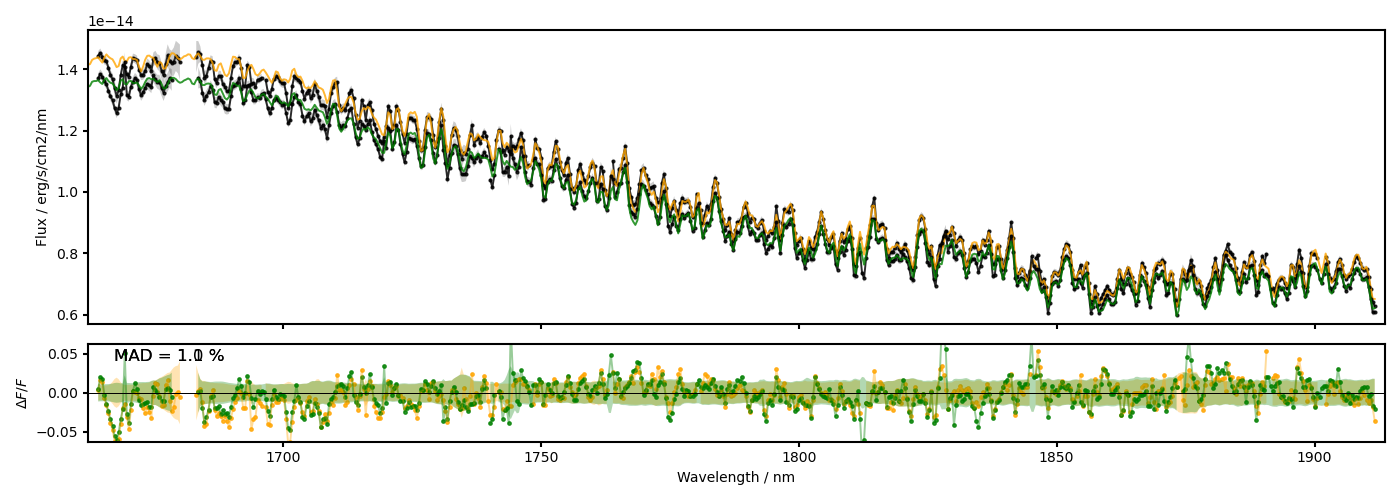

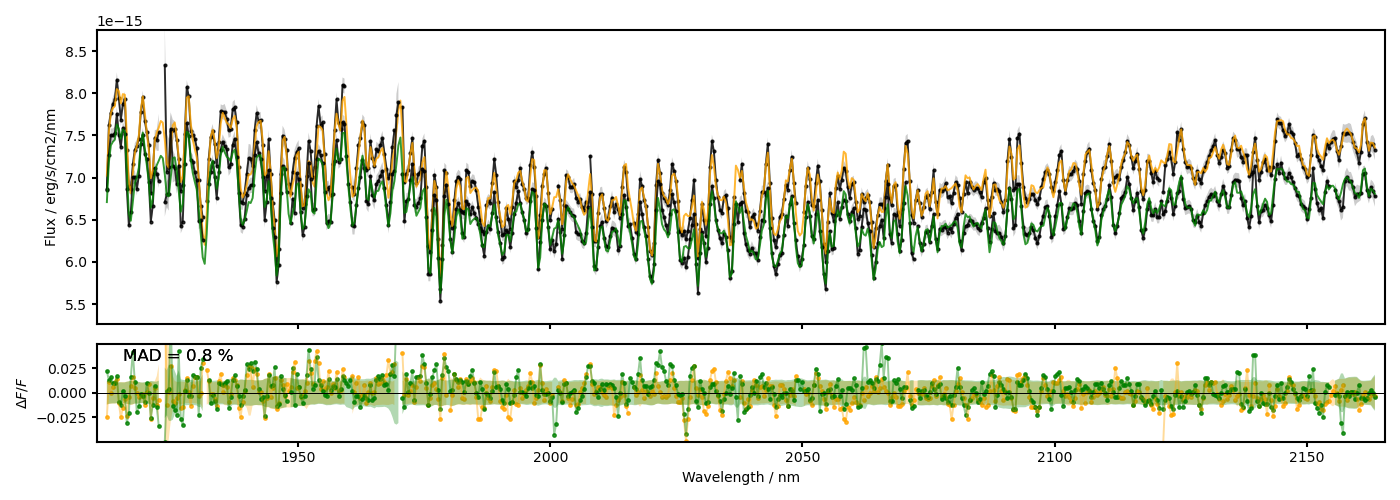

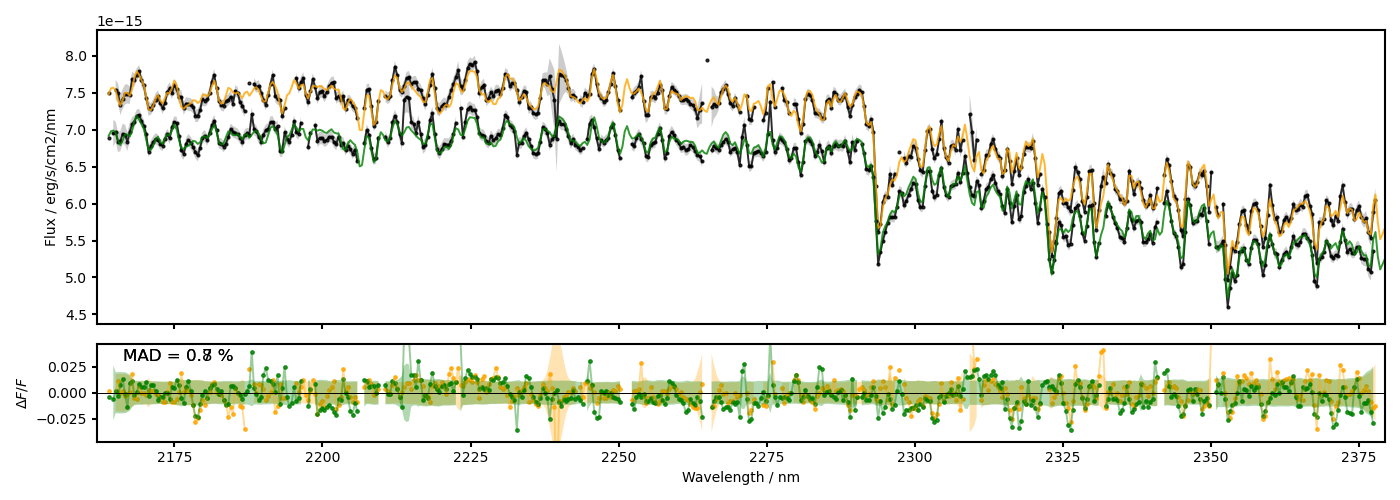

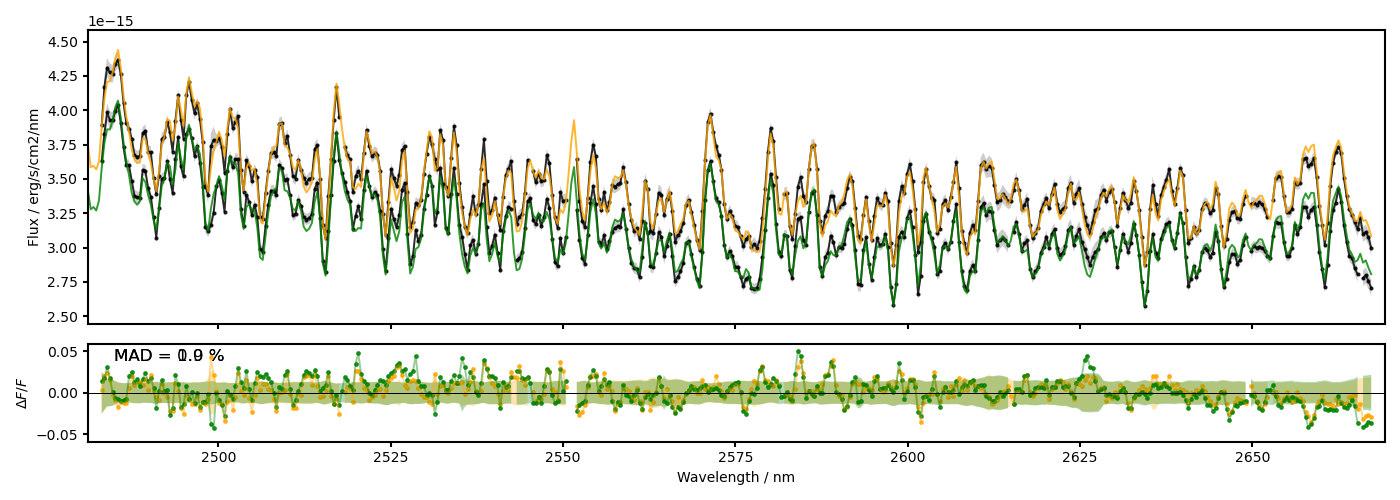

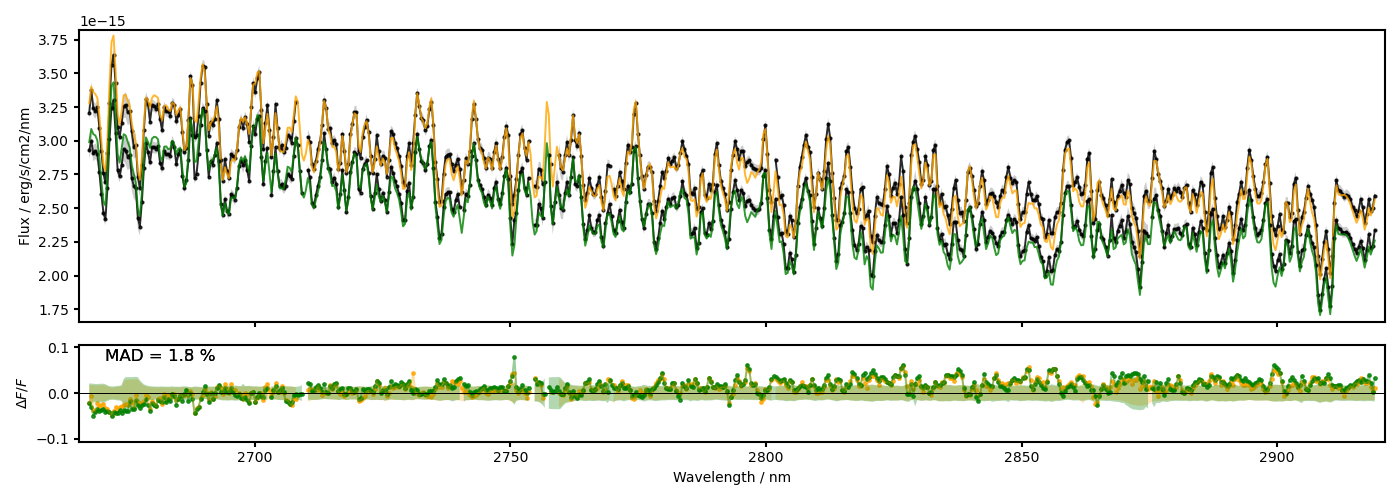

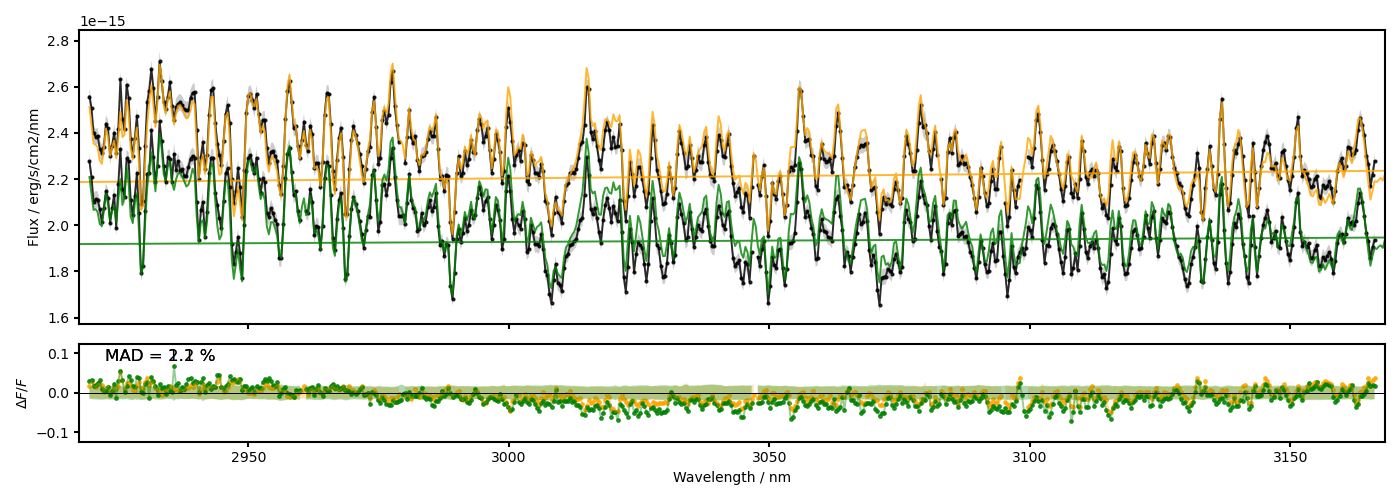

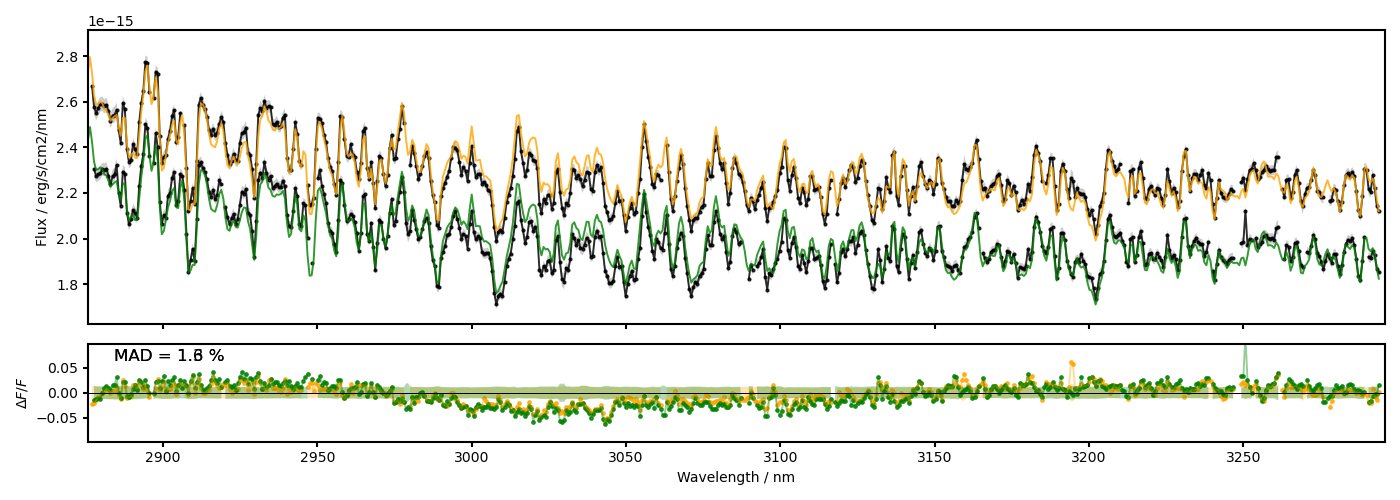

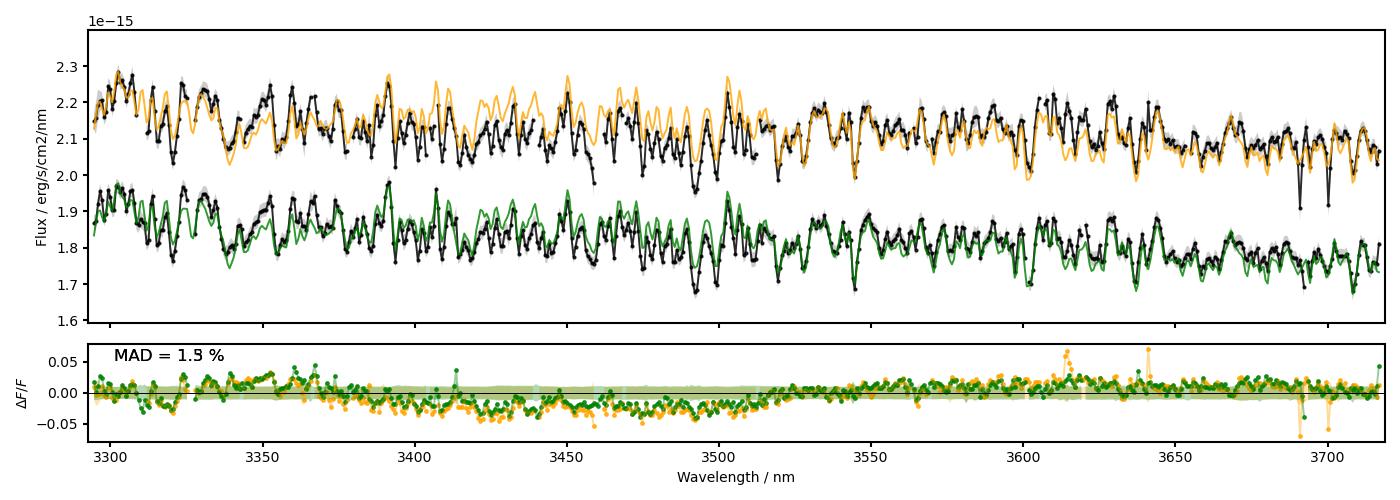

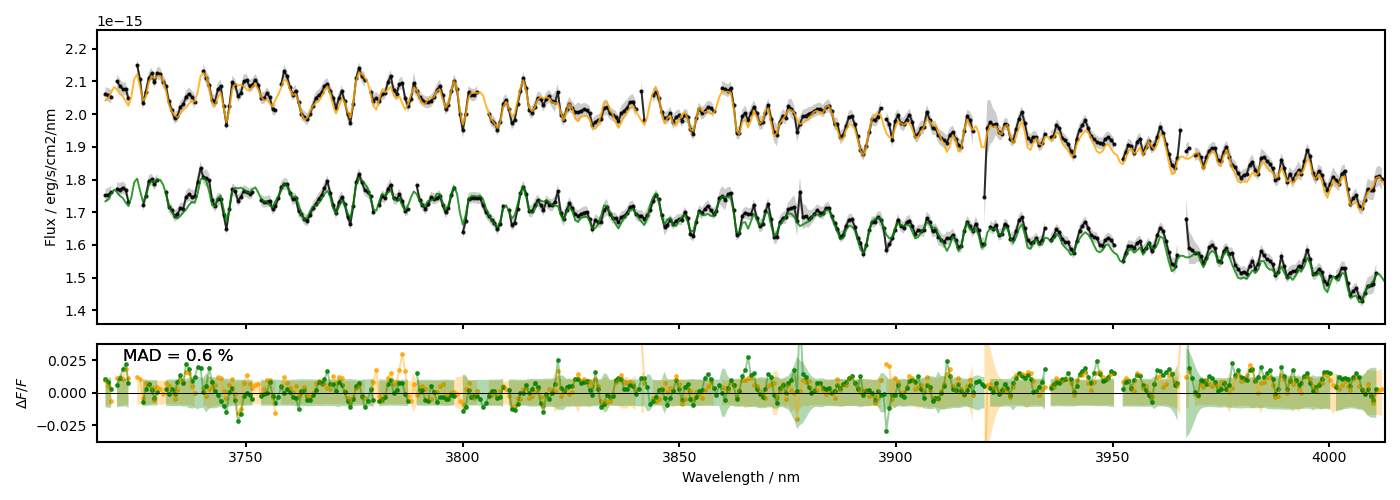

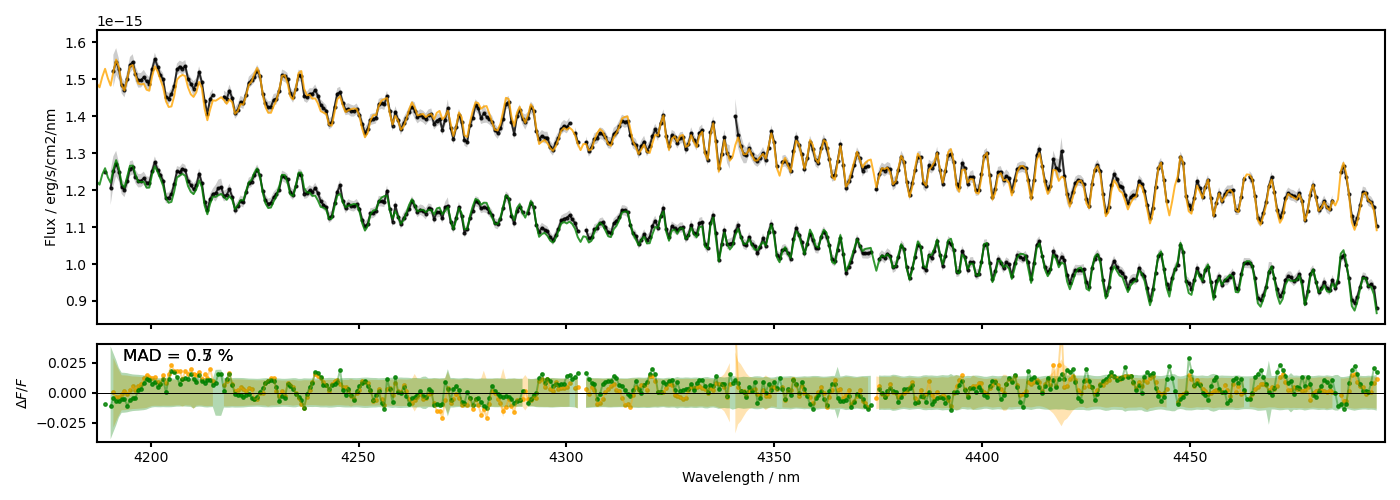

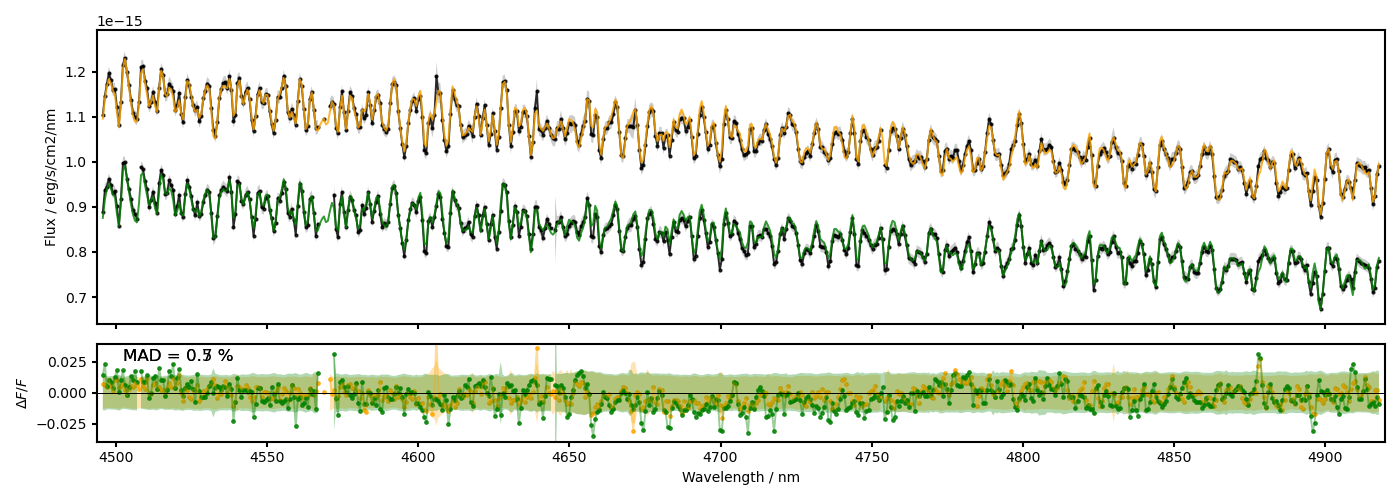

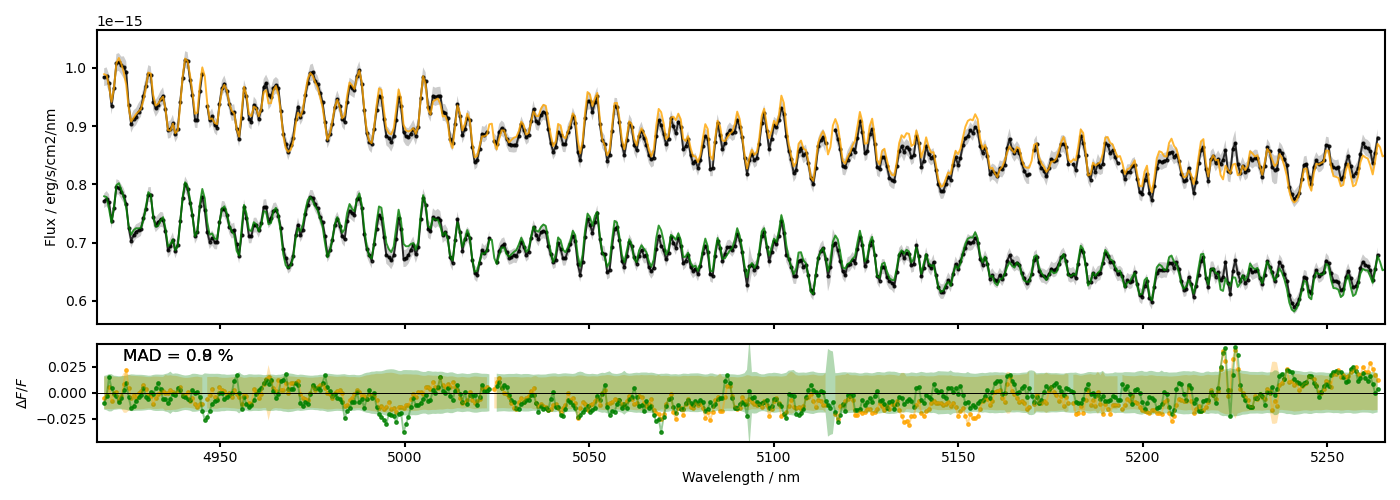

In [10]:
# %matplotb notebook
%matplotlib widget

ymins = np.min(np.array([np.nanmin(d_specs[t].flux, axis=(1)) for t in runs.keys()]),axis=0)
ymaxs = np.max(np.array([np.nanmax(d_specs[t].flux, axis=(1)) for t in runs.keys()]),axis=0)
for idx in range(d_specs['TWA28'].flux.shape[0]):
    plot_idx(idx, ylim=(ymins[idx]*0.95, ymaxs[idx]*1.05))

Filename: /home/dario/phd/retrieval_base/data/jwst_nirspec_f290lp_trans.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      39   ()      
  1  TABLE         1 BinTableHDU     15   153R x 2C   [E, E]   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2015-09-08T14:52:09' / UTC-GMT creation time                         REFTYPE = 'FILTER  '           / reference file type                            TELESCOP= 'JWST    '           / telescope                                      LITREF  = 'NTN-2015-017 -- ESA-JWST-TN-21424' /literature reference             AUTHOR  = 'Pierre Ferruit'     / author                                         FILETYPE= 'THROUGHPUT

Text(0, 0.5, 'Transmission')

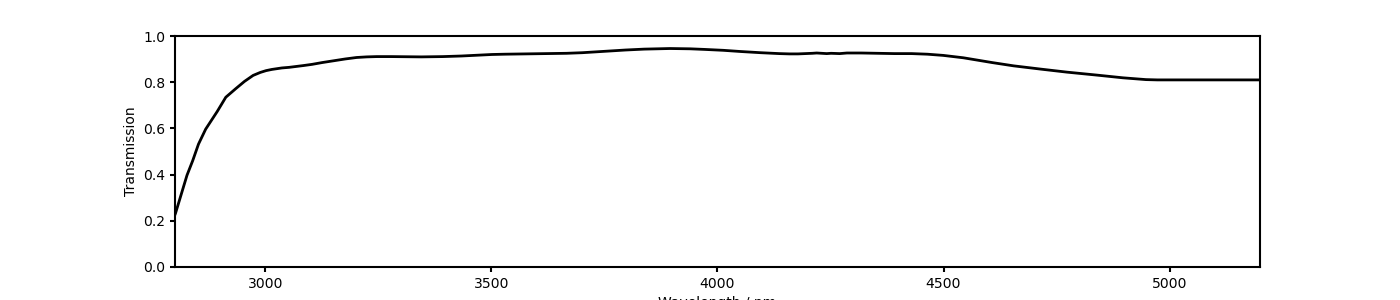

In [189]:
# load transmission files 
from astropy.io import fits
file_transmission = '/home/dario/phd/retrieval_base/data/jwst_nirspec_f290lp_trans.fits'
with fits.open(file_transmission) as hdul:
    print(hdul.info())
    hdr = hdul[0].header
    print(hdr)
    wave_transm = hdul[1].data['WAVELENGTH']
    transm = hdul[1].data['THROUGHPUT']


fig, ax = plt.subplots(1,1, figsize=(14,3))
ax.plot(wave_transm*1e3, transm, color='k', lw=2)

xlim = (2800, 5200)
ax.set_xlim(xlim)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel('Wavelength / nm')
ax.set_ylabel('Transmission')



Filename: /home/dario/phd/retrieval_base/twx_figs/IFU_PCE/comm_PCE_F290LP_G395H_IFU.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  PCE           1 BinTableHDU     15   3309R x 2C   [E, E]   
None


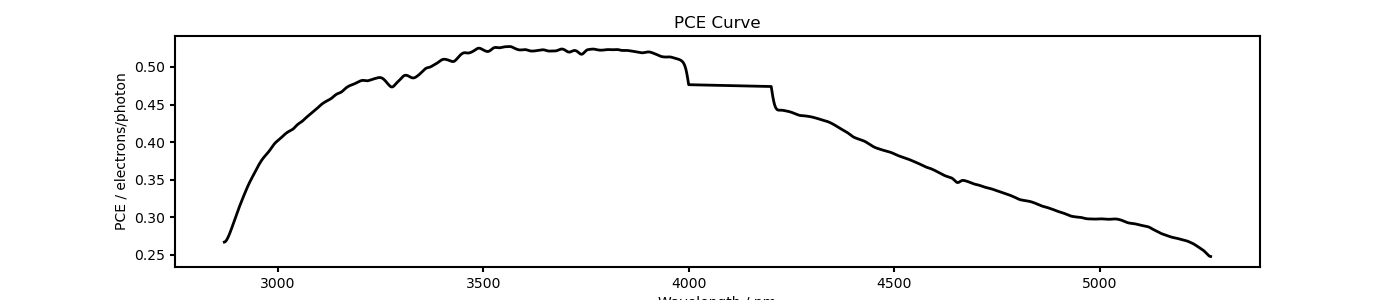

In [190]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib

from astropy.io import fits
from scipy.ndimage import gaussian_filter
path  = pathlib.Path("/home/dario/phd/retrieval_base/twx_figs")
file = path / 'IFU_PCE' / 'comm_PCE_F290LP_G395H_IFU.fits'

with fits.open(file) as hdu:
    print(hdu.info())
    data = hdu[1].data
    
wave_pce, pce = data['Wavelength'], data['Obs. PCE']
wave_pce *= 1e9 # [m] -> [nm]
# apply gaussian smoothing to the PCE curve
pce_smooth = gaussian_filter(pce, sigma=10)

fig, ax = plt.subplots(1,1, figsize=(14,3))
ax.plot(wave_pce, pce_smooth, color='k', lw=2)
ax.set_xlabel('Wavelength / nm')
ax.set_ylabel('PCE / electrons/photon')
ax.set_title('PCE Curve')
plt.show()


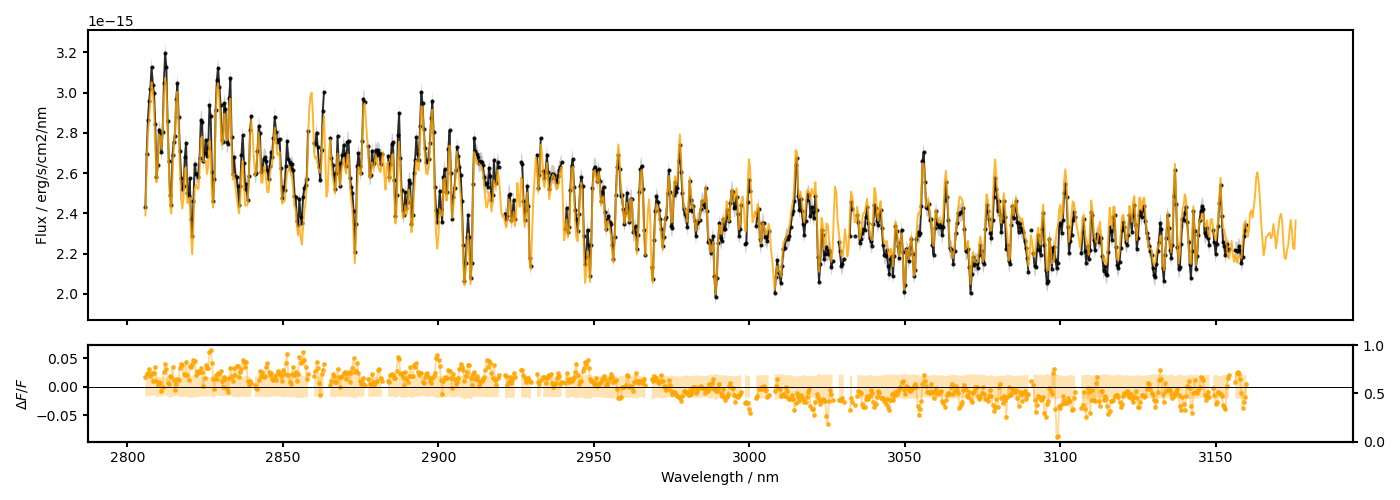

In [191]:

fig, ax = fig_ax()
idx = 7
wave_idx, flux_idx, err_idx = plot_idx(idx, fig=fig, ax=ax, ylim=(ymins[idx]*0.95, ymaxs[idx]*1.05), targets=['TWA28'])


mask_transm = (wave_transm*1e3 > np.min(wave_idx)) & (wave_transm*1e3 < np.max(wave_idx))
ax_twinx = ax[1].twinx()
# ax_twinx.plot(wave_transm[mask_transm]*1e3,transm[mask_transm]/np.max(transm[mask_transm]), color='k', lw=2)

# mask_pce = (wave_pce > np.min(wave_idx)) & (wave_pce < np.max(wave_idx))
# ax_twinx.plot(wave_pce[mask_pce], pce_smooth[mask_pce] / np.max(pce_smooth[mask_pce]), color='k', lw=2)
# ax[1].set_ylim(-0.1, 0.1)



In [192]:
m_specs['TWA28'].flux.shape

(12, 987)

In [193]:
d_specs['TWA28'].flux.shape

(12, 987)

In [210]:
# grating = 'g395h'
gratings = ['g140h', 'g235h', 'g395h']
n_ap = 5

new_data  = {}

for n_ap in [4,5]:
    wave_new, flux_new, err_new = [], [], []
    for grating in gratings:
        
        file_new = f'/home/dario/phd/retrieval_base/TWA28/jwst/{grating}_s3d_extraction_{n_ap}ap.npy'

        load_data = np.load(file_new)
        print(load_data.shape)
        print(f'wavelength range: {np.nanmin(load_data[0])} - {np.nanmax(load_data[0])} nm')
        wave_new.append(load_data[0])
        flux_new.append(load_data[1])
        err_new.append(load_data[2])
        
    wave_new_array = np.concatenate(wave_new)
    flux_new_array = np.concatenate(flux_new)
    err_new_array = np.concatenate(err_new)

    new_data[f'ap{n_ap}'] = {'wave': wave_new_array, 'flux': flux_new_array, 'err': err_new_array}

print(wave_new_array.shape)

(3, 3915)
wavelength range: 970.1175286099897 - 1889.9075267327134 nm
(3, 3814)
wavelength range: 1660.1979666156694 - 3170.1459229225293 nm
(3, 3610)
wavelength range: 2870.332385558868 - 5270.317384012742 nm
(3, 3915)
wavelength range: 970.1175286099897 - 1889.9075267327134 nm
(3, 3814)
wavelength range: 1660.1979666156694 - 3170.1459229225293 nm
(3, 3610)
wavelength range: 2870.332385558868 - 5270.317384012742 nm
(11339,)


In [211]:
# compare new extraction with old one


from matplotlib.backends.backend_pdf import PdfPages

def plot_new_data(idx, pdf=None, normalize=True, n_ap=5):
    # print(f' loaded new data with wavelength range {np.nanmin(wave_new)} - {np.nanmax(wave_new)} nm')
   
    wave_new, flux_new, err_new = new_data[f'ap{n_ap}']['wave'], new_data[f'ap{n_ap}']['flux'], new_data[f'ap{n_ap}']['err']
    
    wave_idx, flux_idx, err_idx = d_specs['TWA28'].wave[idx], d_specs['TWA28'].flux[idx], d_specs['TWA28'].err[idx]
    mask_new = (wave_new > np.nanmin(wave_idx)) & (wave_new < np.nanmax(wave_idx))
    # assert not np.all(flux_new[mask_new] == 0.0), 'flux_new is all zeros'
    if np.all(flux_new[mask_new] == 0.0):
        return
    m_flux = m_specs['TWA28'].flux[idx]
    nans = np.isnan(flux_idx)
    m_flux[nans] = np.nan
    
    m_flux_norm = m_flux / np.nanmedian(m_flux) if normalize else m_flux

    flux_idx_median = np.nanmedian(flux_idx) if normalize else 1.0
    flux_idx_norm = flux_idx / flux_idx_median
    # err_idx_norm = err_idx / flux_idx_median
    snr_idx = flux_idx / np.where(err_idx == 0.0, np.nan, err_idx)
    print(f' Median SNR of M24 (fitted error): {np.nanmedian(snr_idx):.2f}')
    # fig, ax = fig_ax()
    fig, ax = plt.subplots(2,1, figsize=(14,6), sharex=True, gridspec_kw={'height_ratios':[3,1]})

    ax[0].plot(wave_idx, flux_idx_norm, color='k', lw=1, label='M24')
    # ax[0].fill_between(wave_idx, flux_idx_norm - err_idx_norm, flux_idx_norm + err_idx_norm, color='k', alpha=0.2, lw=0.0)

    flux_new_median = np.nanmedian(flux_new[mask_new]) if normalize else 1.0
    flux_new_norm = flux_new / flux_new_median
    # err_new_norm = err_new / flux_new_median
    snr_new = flux_new / np.where(err_new == 0.0, np.nan, err_new)
    assert not np.all(flux_new_norm == 0.0), 'flux_new_norm is all zeros'
    print(f' Median SNR of new data: {np.nanmedian(snr_new):.2f}')
    ax[0].plot(wave_new[mask_new], flux_new_norm[mask_new], color='orangered', lw=1, label='new data')
    # ax[0].fill_between(wave_new[mask_new], flux_new_norm[mask_new] - err_new_norm[mask_new], flux_new_norm[mask_new] + err_new_norm[mask_new], color='orangered', alpha=0.2, lw=0.0)


    ax[0].plot(wave_idx, m_flux_norm, color='seagreen', lw=1, label='best fit')

    residuals = flux_idx_norm - np.interp(wave_idx, wave_new, flux_new_norm)
    residuals_new = (m_flux_norm - np.interp(wave_idx, wave_new, flux_new_norm))

    residuals_bestfit = flux_idx_norm - m_flux_norm
    ax[1].plot(wave_idx, residuals, color='orangered', lw=1, label='M24 - new data')
    # ax[1].plot(wave_idx, residuals_new, color='orangered', lw=1, label='best fit - new extraction')
    ax[1].plot(wave_idx, residuals_bestfit, color='seagreen', lw=1, label='M24 - best fit', alpha=0.8)
    ax[1].axhline(0.0, color='k', lw=0.7)

    ax[0].legend()
    ax[1].legend()
    # add labels
    ax[-1].set_xlabel('Wavelength / nm')
    ax[0].set_ylabel('Flux')
    ax[1].set_ylabel('Residuals')
    ax[-1].set_xlim(np.nanmin(wave_idx), np.nanmax(wave_idx))
    plt.tight_layout()
    if pdf is not None:
        pdf.savefig(fig)
    plt.close(fig)

# Create and save the multi-page PDF
normalize = False


for n_ap in [4,5]:
    
    label_norm = '_normalized' if normalize else ''
    output_path = path_figures / f'new_vs_old_extraction_{n_ap}ap_comparison{label_norm}.pdf'
    with PdfPages(output_path) as pdf:
        for idx in range(d_specs['TWA28'].flux.shape[0]):
            
            plot_new_data(idx, pdf=pdf, normalize=normalize, n_ap=n_ap)

print(f"PDF saved to {output_path}")

 Median SNR of M24 (fitted error): 24.10
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 32.41
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 36.22
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 32.97
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 45.75
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 60.13
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 57.09
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 51.88
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 50.25
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 86.60
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 116.76
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 119.34
 Median SNR of new data: 877.41
 Median SNR of M24 (fitted error): 24.10
 Median SNR of new data: 898.59
 Median SNR of M24 (fitted error): 32.41
 Median 

In [196]:
wave_new.shape

(11339,)